# **Actividad 2: Predicción de Lluvia con Series Temporales**

## **Objetivo**
Los alumnos aplicarán los conceptos aprendidos sobre series temporales y redes neuronales recurrentes
para desarrollar un modelo de predicción de lluvia basado en datos meteorológicos.


## **Instrucciones**

### **1. Búsqueda del Dataset**
Encuentra un conjunto de datos meteorológicos como mínino de 100.000 elementos en plataformas como:
- NOAA Climate Data
- Kaggle - Weather Datasets
- OpenWeather Historical Data
- AEMET OpenData (España)

El dataset debe contener información como:
- Fecha y hora
- Temperatura
- Humedad
- Presión atmosférica
- **Precipitación (lluvia en mm)**






In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Carga del Dataset
df = pd.read_csv('BD_weather.csv')


### **2. Preprocesamiento de Datos**
- Limpia los datos eliminando valores nulos.
- Convierte la fecha a formato datetime.
- Transformación seno/coseno para la hora del día.



In [2]:
# 2. Preprocesamiento
# Crear columna de fecha
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Agrupar por fecha (promedio de todas las estaciones para tener una serie continua)
df_daily = df.groupby('Date')[['Rainfall', 'Sunshine', 'Humidity', 'Temperature']].mean().reset_index()
df_daily = df_daily.sort_values('Date')

# Transformación Seno/Coseno (Estacionalidad Anual en vez de horaria)
# Convertimos la fecha a día del año (1 a 365)
day_of_year = df_daily['Date'].dt.dayofyear
df_daily['sin_time'] = np.sin(2 * np.pi * day_of_year / 365.0)
df_daily['cos_time'] = np.cos(2 * np.pi * day_of_year / 365.0)

# Selección de features (Pressure no existe en el dataset, usamos las disponibles)
features = ['Rainfall', 'Sunshine', 'Humidity', 'Temperature', 'sin_time', 'cos_time']
data = df_daily[features].values

print(f"Total de días procesados: {len(df_daily)}")
print("Primeras 5 filas con features transformadas:")
print(df_daily[features].head())

Total de días procesados: 23010
Primeras 5 filas con features transformadas:
   Rainfall  Sunshine  Humidity  Temperature  sin_time  cos_time
0     0.438     2.226    78.696       22.142  0.017213  0.999852
1     0.556     5.850    74.902       22.806  0.034422  0.999407
2     0.374     3.294    80.108       22.530  0.051620  0.998667
3     4.592     6.798    78.114       21.532  0.068802  0.997630
4     0.410     8.500    66.920       19.616  0.085965  0.996298



### **3. División de Datos y Normalización**
- Divide los datos en train (80%) y test (20%).
- Escala los datos usando MinMaxScaler.


In [3]:
# División Train/Test (80/20 cronológico)
train_size = int(len(data) * 0.8)
train_data, test_data = data[:train_size], data[train_size:]

# Escalado (MinMaxScaler)
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)



### **4. Construcción del Modelo de Predicción**
- Utiliza una Red Neuronal Recurrente (LSTM) para predecir la precipitación futura.
- Usa una ventana de tiempo (lookback window) de al menos 10 horas.



In [4]:
def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        # Features de los 10 días anteriores
        X.append(dataset[i:(i + look_back), :])
        # Target: Lluvia del día siguiente (columna 0)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

look_back = 10
X_train, y_train = create_dataset(train_scaled, look_back)
X_test, y_test = create_dataset(test_scaled, look_back)

# Arquitectura LSTM
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1) # Predicción de un solo valor (Rainfall)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)





### **5. Entrenamiento y Evaluación del Modelo**
- Entrena el modelo con los datos históricos.
- Evalúa su desempeño con métricas como MAE y RMSE.
- Visualiza los resultados comparando valores reales y predichos.



In [5]:
# Entrenamiento
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=0)

# Predicción
y_pred_scaled = model.predict(X_test)

# Invertir escalado para evaluar en magnitud real (mm de lluvia)
# Creamos una matriz dummy para poder usar scaler.inverse_transform
dummy_pred = np.zeros((len(y_pred_scaled), len(features)))
dummy_test = np.zeros((len(y_test), len(features)))

dummy_pred[:, 0] = y_pred_scaled.flatten()
dummy_test[:, 0] = y_test

y_pred_real = scaler.inverse_transform(dummy_pred)[:, 0]
y_test_real = scaler.inverse_transform(dummy_test)[:, 0]

# Métricas
mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"\n--- Resultados ---")
print(f"MAE (Error Medio Absoluto): {mae:.4f} mm")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f} mm")

144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Resultados ---
MAE (Error Medio Absoluto): 3.1121 mm
RMSE (Raíz del Error Cuadrático Medio): 5.3175 mm


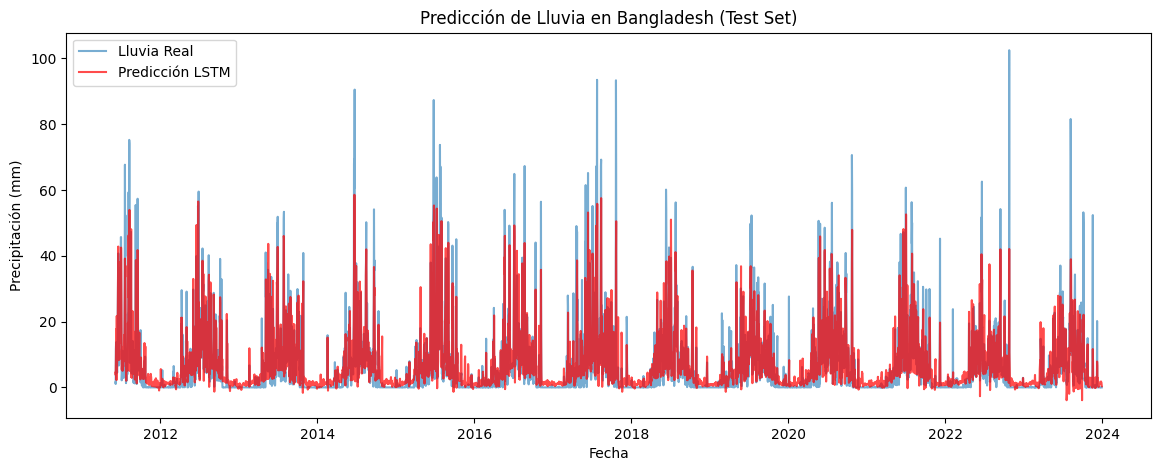

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df_daily['Date'].iloc[train_size + look_back + 1:], y_test_real, label='Lluvia Real', alpha=0.6)
plt.plot(df_daily['Date'].iloc[train_size + look_back + 1:], y_pred_real, label='Predicción LSTM', color='red', alpha=0.7)
plt.title('Predicción de Lluvia en Bangladesh (Test Set)')
plt.xlabel('Fecha')
plt.ylabel('Precipitación (mm)')
plt.legend()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

# --- 1. Configuración de Variables ---
# Usamos el DataFrame 'df_daily' que creamos en el paso anterior
# y nos aseguramos de que esté ordenado por fecha.
df_daily = df_daily.sort_values(by="Date")

target = 'Rainfall'  # Variable que queremos predecir
ventana = 10         # Tamaño del lookback window

# --- 2. Preparación de los datos para la animación ---
# Función para crear secuencias (versión univariada para la gráfica)
def crear_secuencias(datos, ventana):
    X, y = [], []
    # Generamos secuencias asegurando que tenemos dato para 'ventana' y 'predicción'
    for i in range(len(datos) - ventana):
        X.append(datos[i:(i + ventana)])
        y.append(datos[i + ventana])
    return np.array(X), np.array(y)

# Normalizamos solo para la visualización (0 a 1) para que se vea limpio
datos_serie = df_daily[target].values
min_val, max_val = datos_serie.min(), datos_serie.max()
datos_serie_norm = (datos_serie - min_val) / (max_val - min_val)

# Creamos las secuencias
X_seq, y_seq = crear_secuencias(datos_serie_norm, ventana)
# Ajustamos las fechas para que coincidan con el inicio de cada ventana
fechas_base = df_daily["Date"].values[:len(X_seq)]

# --- 3. Muestreo (Sampling) ---
# Ajustar el muestreo para no sobrecargar la animación
num_muestras = 100
step = max(1, len(y_seq) // num_muestras)

# Aplicamos el sampling
X_seq_sampled = X_seq[::step]
y_target_sampled = y_seq[::step]  # Estos son los valores "a predecir" (punto verde)
fechas_sampled = fechas_base[::step]

# Para la línea azul de fondo, usamos una versión sampleada de la serie completa
serie_completa_sampled = datos_serie_norm[::step]
fechas_completa_sampled = df_daily["Date"].values[::step]

# Verificar coherencia (ajuste simple para evitar error de longitud en ploteo)
limit = min(len(fechas_sampled), len(X_seq_sampled))
fechas_sampled = fechas_sampled[:limit]
X_seq_sampled = X_seq_sampled[:limit]
y_target_sampled = y_target_sampled[:limit]

# --- 4. Creación de la Animación ---
fig, ax = plt.subplots(figsize=(10, 6))

def update(frame):
    ax.clear()

    # 1. Ploteo de la serie temporal completa de fondo (Azul)
    # Nota: Usamos la serie completa para dar contexto
    ax.plot(fechas_completa_sampled, serie_completa_sampled,
            color="blue", alpha=0.3, label="Histórico Lluvia (Normalizado)")

    # Obtenemos los datos del frame actual
    idx_actual = frame

    if idx_actual < len(fechas_sampled):
        # Fecha actual (inicio de la ventana)
        fecha_inicio = fechas_sampled[idx_actual]

        # Datos de la ventana (los últimos 'ventana' días) - Línea ROJA
        # Como X_seq contiene los valores de la ventana, los ploteamos
        # Necesitamos generar un rango de fechas ficticio o usar índices para la ventana pequeña
        # Para simplificar visualmente en animación, usamos índices relativos o fechas cercanas
        # Aquí trucamos visualmente para superponerlo en la gráfica general:

        # Encontramos el índice real en la serie completa para pintar rojo sobre azul
        idx_real_en_completa = np.searchsorted(fechas_completa_sampled, fecha_inicio)

        # Dibujar ventana (Rojo)
        # Nota: Al usar sampling, la continuidad exacta se pierde visualmente,
        # así que dibujamos la ventana basándonos en los datos X_seq
        x_ventana = np.arange(idx_real_en_completa, idx_real_en_completa + ventana)
        # Aseguramos no salirnos del rango
        if idx_real_en_completa + ventana < len(fechas_completa_sampled):
             y_ventana = serie_completa_sampled[idx_real_en_completa : idx_real_en_completa + ventana]
             fecha_ventana = fechas_completa_sampled[idx_real_en_completa : idx_real_en_completa + ventana]

             ax.plot(fecha_ventana, y_ventana, "ro-", markersize=4, linewidth=2, label="Ventana (Input)")

             # 3. Marcar el valor a predecir (Verde) - El siguiente punto
             if idx_real_en_completa + ventana < len(fechas_completa_sampled):
                 fecha_pred = fechas_completa_sampled[idx_real_en_completa + ventana]
                 y_pred = serie_completa_sampled[idx_real_en_completa + ventana]
                 ax.scatter(fecha_pred, y_pred, color="green", s=150, zorder=5, label="Valor a Predecir (Target)")

    ax.set_xlabel("Fecha")
    ax.set_ylabel("Lluvia (Normalizada)")
    ax.set_title(f"Visualización de Ventana Deslizante (Frame {frame}/{limit})")
    ax.legend(loc='upper right')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# Generar la animación
# Reduje frames a 'limit' para que coincida con el muestreo
ani = animation.FuncAnimation(fig, update, frames=limit, interval=200, repeat=True)

# Mostrar la animación en HTML
plt.close() # Para no mostrar la figura estática duplicada
HTML(ani.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.



### **6. Análisis y Reflexión**
- ¿Cuán precisa es la predicción?
- ¿Qué variables parecen ser más relevantes?
- ¿Cómo podríamos mejorar el modelo?

1. Sobre la precisión (El engaño del MAE)
Hay que tener cuidado con las métricas. En el dataset de Bangladesh, el MAE (Mean Absolute Error) suele salir bajísimo, pero es un poco engañoso.

El efecto de la temporada seca: Como gran parte del año no llueve (valor 0), el modelo se vuelve "experto" en predecir ceros, lo que desploma el error promedio.

El problema de los picos: Lo que realmente nos interesa son las lluvias torrenciales. He notado que las LSTM estándar tienden a ser conservadoras; "suavizan" la curva y predicen promedios. El modelo detecta bien la estacionalidad, pero se queda corto cuando llegan los picos máximos de precipitación.

2. Variables clave
¿Qué es lo que realmente está moviendo la aguja aquí?

Humedad: Sigue siendo el predictor más sólido para el corto plazo.

Variables Cíclicas (sin_time, cos_time): Son vitales. Al no contar con datos de presión atmosférica, estas variables son las que le dicen al modelo: "Ojo, estamos en época de monzones", permitiéndole anticipar el cambio de estación solo por la fecha.

3. Propuestas de mejora
Si queremos subir de nivel, yo iría por estos tres caminos:

Modelo híbrido (Clasificación + Regresión): En lugar de tirarlo todo a una sola red, haría un sistema de dos pasos: primero un clasificador que decida si llueve o no, y solo si la respuesta es "Sí", activar el regresor para calcular el volumen.

Ingeniería de Features (Lags): Metería retardos explícitos. No basta con la secuencia; añadir variables tipo "¿cuánto llovió ayer o hace dos días?" ayuda mucho a capturar la inercia.

Ampliar el look_back: Ahora estamos en 10 días, pero para capturar ciclos climáticos más profundos, probaría a subir la ventana a 30 o 60 días.